In [1]:
# =====================================================
# A) common_h2.py  (SHARED BY ALL METHODS) — notebook-friendly
# RL (no-forecast) adjusted to match your final COMMON + MPC constants/constraints
# so the ONLY difference is the control method (RL vs MPC vs RBC).
# =====================================================

import numpy as np

# -------------------------
# 1) Time settings
# -------------------------
CONTROL_HORIZON = 1
PREDICTION_HORIZON = 12
T_TOTAL = 168  # 1 week, 1-hour steps
DT_HOURS = 1.0

# -------------------------
# 2) System parameters (physical)
# -------------------------
ETA_CH = 0.95
ETA_DCH = 0.95

KWH_PER_KG = 50.0
ETA_ELEC = (DT_HOURS / KWH_PER_KG)  # kg per timestep per kW

SOC_MAX = 1000.0
P_BAT_MAX = 200.0
P_ELEC_MAX = 300.0
H_STORE_MAX = 1000.0

# Hydrogen storage throughput (kg/h)
H_CH_MAX = 10.0
H_DCH_MAX = 10.0

# Electrolyzer operational constraints
P_ELEC_MIN = 0.2 * P_ELEC_MAX  # 60 kW
RAMP_MAX = 60.0                # kW per hour

# Grid import limit (kW)
P_GRID_MAX = 250.0

# -------------------------
# 3) Economics (units aligned)
# -------------------------
C_GRID_BASE = 40.0  # unused (kept for completeness)
C_BATTERY = 0.03
C_ELEC = 0.01
C_HSTORE = 0.0005

H_PRICE = 10.0
CO2_ADDER = 0.02  # $/kWh

# -------------------------
# 4) Initial states
# -------------------------
SOC_INIT = 500.0
H_STORE_INIT = 20.0

# -------------------------
# 5) RNGs for disturbances (DO NOT re-init inside functions)
# -------------------------
_SOLAR_RNG = np.random.default_rng(0)
_PRICE_RNG = np.random.default_rng(1)
_DEMAND_RNG = np.random.default_rng(2)

# -------------------------
# 6) Real-time disturbance models (truth signals)
# -------------------------
def real_solar(t: int) -> float:
    """
    PV power available at time t [kW].
    Day/night half-sine + slow cloudiness + small noise.
    """
    hod = t % 24
    if hod < 6 or hod > 18:
        base = 0.0
    else:
        x = (hod - 6) / 12.0
        base = np.sin(np.pi * x)

    P_PV_PEAK = 300
    day = t // 24
    cloud = 0.75 + 0.20 * np.sin(2*np.pi*day/7.0)
    noise = _SOLAR_RNG.normal(0.0, 0.03)

    return float(max(0.0, P_PV_PEAK * base * (cloud + noise)))

def real_grid_price(t: int) -> float:
    """
    Electricity price [$/kWh].
    Time-of-use + rare spikes.
    """
    hod = t % 24
    if 0 <= hod < 6:
        p = 0.08
    elif 6 <= hod < 16:
        p = 0.12
    elif 16 <= hod < 21:
        p = 0.28
    else:
        p = 0.15

    if _PRICE_RNG.random() < 0.02:
        p *= 2.5

    return float(p)

def real_hydrogen_demand(t: int) -> float:
    """
    Hydrogen demand [kg/h] at time t.
    Scaled to match 300 kW electrolyzer (~6 kg/h max).
    """
    hod = t % 24
    base = 3.5 + 1.5*np.sin(2*np.pi*(hod-8)/24.0)  # ~2..5
    day = t // 24
    weekly = 0.3*np.sin(2*np.pi*day/7.0)
    noise = _DEMAND_RNG.normal(0.0, 0.25)

    return float(max(0.0, base + weekly + noise))

# -------------------------
# 7) Forecast model (used by MPC and RL+Forecast)
# (not used by RL no-forecast, but kept here for completeness)
# -------------------------
SIGMA_SOLAR0 = 10.0
SIGMA_PRICE0 = 0.02
SIGMA_DEMAND0 = 0.5
ALPHA = 0.8

def forecast_with_uncertainty(real_func, t_now: int, delta: int, rng: np.random.Generator, sigma0: float):
    std = float(sigma0 * np.sqrt(1.0 + ALPHA * float(delta)))
    value = float(real_func(t_now + delta) + rng.normal(0.0, std))
    return value, std

# -------------------------
# 8) Common logger + KPI tools
# -------------------------
def init_logs():
    return {k: [] for k in [
        "E_sb","E_sp","E_be","E_ge","P_elec",
        "H_prod","H_sales","H_es","H_est","H_ss",
        "SOC","H_store","solar"
    ]}

def compute_kpis(logs: dict) -> dict:
    time = np.arange(len(logs["E_sb"]))

    E_sb = np.asarray(logs["E_sb"], dtype=float)
    E_be = np.asarray(logs["E_be"], dtype=float)
    E_ge = np.asarray(logs["E_ge"], dtype=float)
    P_elec = np.asarray(logs["P_elec"], dtype=float)

    H_prod = np.asarray(logs["H_prod"], dtype=float)
    H_sales = np.asarray(logs["H_sales"], dtype=float)
    H_es = np.asarray(logs["H_es"], dtype=float)
    H_est = np.asarray(logs["H_est"], dtype=float)
    H_ss = np.asarray(logs["H_ss"], dtype=float)

    H_store = np.asarray(logs["H_store"], dtype=float)

    solar_to_battery = float(np.sum(E_sb))
    solar_to_electrolyzer = float(np.sum(P_elec - E_be - E_ge))  # approx (same as your common)
    battery_discharge = float(np.sum(E_be))
    grid_energy = float(np.sum(E_ge))
    electrolyzer_energy = float(np.sum(P_elec))

    hydrogen_produced = float(np.sum(H_prod))
    hydrogen_sold_total = float(np.sum(H_sales))
    hydrogen_sold_from_prod = float(np.sum(H_es))
    hydrogen_sold_from_storage = float(np.sum(H_ss))
    hydrogen_to_storage = float(np.sum(H_est))

    grid_prices = np.array([real_grid_price(int(t)) for t in time], dtype=float)
    grid_cost = float(np.sum(E_ge * (grid_prices + CO2_ADDER)))
    battery_cost = float(np.sum(C_BATTERY * (E_sb + E_be)))
    electrolyzer_cost = float(np.sum(C_ELEC * P_elec))
    storage_cost = float(np.sum(C_HSTORE * H_store))
    total_cost = float(grid_cost + battery_cost + electrolyzer_cost + storage_cost)

    revenue = float(np.sum(H_PRICE * H_sales))
    net_profit = float(revenue - total_cost)

    return {
        "Solar Used (E_se)": solar_to_electrolyzer,
        "Grid Energy Used (E_ge)": grid_energy,
        "Battery Charge (E_sb)": solar_to_battery,
        "Battery Discharge (E_be)": battery_discharge,
        "Electrolyzer Energy": electrolyzer_energy,

        "Hydrogen Produced": hydrogen_produced,
        "Hydrogen Sold (Total)": hydrogen_sold_total,
        "Hydrogen Sold from Production (H_es)": hydrogen_sold_from_prod,
        "Hydrogen Sold from Storage (H_ss)": hydrogen_sold_from_storage,
        "Hydrogen Stored (H_est)": hydrogen_to_storage,

        "Revenue ($)": revenue,
        "Grid Cost ($)": grid_cost,
        "Battery Cost ($)": battery_cost,
        "Electrolyzer Cost ($)": electrolyzer_cost,
        "Storage Cost ($)": storage_cost,
        "Total Cost ($)": total_cost,
        "Net Profit ($)": net_profit,

        "H₂ Utilization (%)": float(100 * hydrogen_sold_total / (hydrogen_produced + H_STORE_INIT)) if hydrogen_produced > 0 else 0.0
    }

import matplotlib.pyplot as plt
import numpy as np

def plot_kpis(kpi_values: dict, title_suffix: str = "") -> None:
    """
    Publication-ready KPI plots (identical formatting across RBC/MPC/RL).
    - Removes efficiency panel
    - Thicker bar outlines (print-friendly)
    - Lighter grid
    - Cleaner numeric annotations
    """

    categories = {
        "Energy (kWh)": [
            "Solar Used (E_se)", "Grid Energy Used (E_ge)",
            "Battery Charge (E_sb)", "Battery Discharge (E_be)",
            "Electrolyzer Energy"
        ],
        "Hydrogen (kg)": [
            "Hydrogen Produced", "Hydrogen Sold (Total)",
            "Hydrogen Sold from Production (H_es)",
            "Hydrogen Sold from Storage (H_ss)",
            "Hydrogen Stored (H_est)"
        ],
        "Cost & Revenue ($)": [
            "Revenue ($)", "Grid Cost ($)", "Battery Cost ($)",
            "Electrolyzer Cost ($)", "Storage Cost ($)",
            "Total Cost ($)", "Net Profit ($)"
        ]
    }

    fig, axs = plt.subplots(len(categories), 1, figsize=(13, 14))
    if len(categories) == 1:
        axs = [axs]

    for ax, (title, keys) in zip(axs, categories.items()):
        values = [float(kpi_values[k]) for k in keys]

        bars = ax.barh(
            keys,
            values,
            edgecolor="black",
            linewidth=1.2,
        )

        ax.set_title(f"{title} {title_suffix}".strip(), fontsize=13)
        ax.set_xlabel(title, fontsize=12)
        ax.grid(True, axis="x", linestyle="--", alpha=0.25)
        ax.set_axisbelow(True)
        ax.tick_params(axis="y", labelsize=11)
        ax.tick_params(axis="x", labelsize=11)

        xpad = 0.01 * (max(abs(v) for v in values) if values else 1.0)

        for bar in bars:
            width = bar.get_width()
            if abs(width) >= 1000:
                label = f"{width:,.0f}"
            elif abs(width) >= 10:
                label = f"{width:.1f}"
            else:
                label = f"{width:.2f}"

            ax.text(
                width + (xpad if width >= 0 else -xpad),
                bar.get_y() + bar.get_height() / 2.0,
                label,
                va="center",
                ha="left" if width >= 0 else "right",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

In [2]:
# =====================================================
# D) rl_no_forecast.py  (METHOD 3: RL without Forecast)
# Notebook-friendly, block-by-block
# Requires:
#   pip install "gymnasium>=0.29" "stable-baselines3>=2.2" "torch>=2.0"
# =====================================================

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.utils import set_random_seed


# -------------------------
# Feasibility layer (action -> feasible physical controls)
# Matches MPC/RBC constraints:
#   - P_GRID_MAX cap
#   - H_CH_MAX / H_DCH_MAX caps
#   - electrolyzer min-load + ON/OFF via action
#   - ramp constraint enforced with previous power
#   - implicit PV curtailment (spill) handled by "unused solar" (not logged)
# -------------------------
def feasibility_layer_no_forecast(
    solar: float,
    price: float,
    demand: float,
    SOC: float,
    H_store: float,
    P_prev: float,
    action: np.ndarray,
):
    """
    Action in [0,1]^3:
      a0 u_on   : ON/OFF (>=0.5 means "intend ON")
      a1 u_pe   : electrolyzer load fraction in [0,1] (applied if ON)
      a2 u_batt : battery mode in [0,1] -> [-1,1] (charge..discharge)

    Returns dict with feasible flows + next states, all aligned with MPC/RBC constraints.

    EDIT: Allocate solar to electrolyzer FIRST; battery charges only from leftover solar.
    """
    a0 = float(np.clip(action[0], 0.0, 1.0))
    a1 = float(np.clip(action[1], 0.0, 1.0))
    a2 = float(np.clip(action[2], 0.0, 1.0))

    intend_on = (a0 >= 0.5)

    # ---- Electrolyzer target with min-load when ON ----
    if intend_on:
        P_target = P_ELEC_MIN + a1 * (P_ELEC_MAX - P_ELEC_MIN)
    else:
        P_target = 0.0

    # ---- Ramp constraint applied to target ----
    P_target = float(np.clip(
        P_target,
        max(0.0, P_prev - RAMP_MAX),
        min(P_ELEC_MAX, P_prev + RAMP_MAX)
    ))

    # ---- Battery mode ----
    batt_mode = 2.0 * (a2 - 0.5)  # [-1,1], -1 charge, +1 discharge
    charge_fraction = max(-batt_mode, 0.0)      # 0..1
    discharge_fraction = max(batt_mode, 0.0)    # 0..1

    # ---------- Use solar for electrolyzer FIRST ----------
    P_from_solar = min(solar, P_target)
    P_elec = P_from_solar
    solar_rem = max(solar - P_from_solar, 0.0)

    # ---------- Battery charge ONLY from remaining solar ----------
    SOC_headroom = max(SOC_MAX - SOC, 0.0)
    E_sb_cap_soc = SOC_headroom / max(ETA_CH, 1e-9)
    E_sb_cap = min(P_BAT_MAX, E_sb_cap_soc)

    E_sb = min(E_sb_cap, solar_rem * charge_fraction)

    # PV spill after optional charging
    E_sp = max(solar_rem - E_sb, 0.0)

    # ---------- Battery discharge to meet P_target ----------
    E_be_cap_soc = SOC * ETA_DCH
    E_be_cap = min(P_BAT_MAX, E_be_cap_soc)

    needed = max(P_target - P_elec, 0.0)
    E_be = min(needed, E_be_cap * discharge_fraction)
    P_elec += E_be

    # ---------- Grid fills remaining gap (capped by P_GRID_MAX) ----------
    needed = max(P_target - P_elec, 0.0)
    E_ge = min(needed, P_GRID_MAX)
    P_elec += E_ge

    # If we intended ON, but can't reach min-load (e.g., ramp/limits), turn off
    if intend_on and (0.0 < P_elec < P_ELEC_MIN):
        P_elec = 0.0
        E_ge = 0.0
        E_be = 0.0
        # keep E_sb as chosen (still can charge battery from PV)

    # hard safety caps
    P_elec = float(np.clip(P_elec, 0.0, P_ELEC_MAX))
    E_sb = float(np.clip(E_sb, 0.0, P_BAT_MAX))
    E_be = float(np.clip(E_be, 0.0, P_BAT_MAX))
    E_ge = float(np.clip(E_ge, 0.0, P_GRID_MAX))
    E_sp = float(max(0.0, E_sp))

    # ---------- Hydrogen production ----------
    H_prod = float(ETA_ELEC * P_elec)

    # ---------- Sell from production first ----------
    H_es = float(min(H_prod, demand))
    demand_left = float(max(demand - H_es, 0.0))

    # ---------- Sell from storage (throughput + inventory) ----------
    H_ss = float(min(H_store, demand_left, H_DCH_MAX))
    H_sales = float(H_es + H_ss)

    # ---------- Store surplus (throughput + headroom) ----------
    surplus = float(max(H_prod - H_es, 0.0))
    headroom = float(max(H_STORE_MAX - H_store, 0.0))
    H_est = float(min(surplus, headroom, H_CH_MAX))

    # ---------- State updates ----------
    SOC_new = float(SOC + ETA_CH * E_sb - E_be / max(ETA_DCH, 1e-9))
    SOC_new = float(np.clip(SOC_new, 0.0, SOC_MAX))

    H_store_new = float(H_store + H_est - H_ss)
    H_store_new = float(np.clip(H_store_new, 0.0, H_STORE_MAX))

    return dict(
        E_sb=E_sb, E_sp=E_sp, E_be=E_be, E_ge=E_ge, P_elec=P_elec,
        H_prod=H_prod, H_es=H_es, H_est=H_est, H_ss=H_ss,
        H_sales=H_sales, SOC_new=SOC_new, H_store_new=H_store_new,
        P_next=P_elec
    )

In [3]:
# -------------------------
# Gym environment (no forecast in observation)
# Observation includes only current state + current disturbances (no future).
# Also includes normalized previous electrolyzer power to help learn ramping.
# -------------------------
class HydrogenEnvNoForecast(gym.Env):
    """
    Observation (normalized to [0,1]):
      [ SOC/SOC_MAX,
        H_store/H_STORE_MAX,
        P_prev/P_ELEC_MAX,
        solar/solar_scale,
        price/price_scale,
        demand/demand_scale ]

    Action:
      3D continuous in [0,1]^3:
        [u_on, u_pe, u_batt]
    """
    metadata = {"render_modes": []}

    def __init__(self, T: int = 168, seed: int = 0):
        super().__init__()
        self.T = int(T)
        self.rng = np.random.default_rng(seed)

        # normalization scales (fixed; not "tuned" between methods)
        self.solar_scale = 300.0   # solar peak ~300
        self.price_scale = 0.75    # spike can go higher; we clip to 1 anyway
        self.demand_scale = 8.0    # demand ~2..5; safe upper scale

        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(6,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=0.0, high=1.0, shape=(3,), dtype=np.float32
        )

        self.t = 0
        self.SOC = float(SOC_INIT)
        self.H_store = float(H_STORE_INIT)
        self.P_prev = 0.0
        self.logs = init_logs()

    def _obs(self):
        s = float(real_solar(self.t))
        p = float(real_grid_price(self.t))
        d = float(real_hydrogen_demand(self.t))
        return np.array([
            self.SOC / SOC_MAX,
            self.H_store / H_STORE_MAX,
            self.P_prev / P_ELEC_MAX,
            np.clip(s / self.solar_scale, 0.0, 1.0),
            np.clip(p / self.price_scale, 0.0, 1.0),
            np.clip(d / self.demand_scale, 0.0, 1.0),
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.t = 0
        self.SOC = float(SOC_INIT)
        self.H_store = float(H_STORE_INIT)
        self.P_prev = 0.0
        self.logs = init_logs()
        return self._obs(), {}

    def step(self, action):
        # real (truth) disturbances at current time
        s = float(real_solar(self.t))
        p = float(real_grid_price(self.t))
        d = float(real_hydrogen_demand(self.t))

        out = feasibility_layer_no_forecast(
            solar=s, price=p, demand=d,
            SOC=self.SOC, H_store=self.H_store,
            P_prev=self.P_prev,
            action=action
        )

        # reward aligned with MPC objective: per-step profit
        revenue = H_PRICE * out["H_sales"]
        cost_grid = (p + CO2_ADDER) * out["E_ge"]
        cost_batt = C_BATTERY * (out["E_sb"] + out["E_be"])
        cost_elec = C_ELEC * out["P_elec"]
        cost_store = C_HSTORE * out["H_store_new"]
        reward = float(revenue - (cost_grid + cost_batt + cost_elec + cost_store))

        # log PRE-update SOC/H_store (match RBC/MPC convention)
        for k in ["E_sb","E_sp","E_be","E_ge","P_elec","H_prod","H_sales","H_es","H_est","H_ss"]:
            self.logs[k].append(float(out[k]))
        self.logs["SOC"].append(float(self.SOC))
        self.logs["H_store"].append(float(self.H_store))
        self.logs["solar"].append(float(s))

        # advance state
        self.SOC = float(out["SOC_new"])
        self.H_store = float(out["H_store_new"])
        self.P_prev = float(out["P_next"])
        self.t += 1

        terminated = self.t >= self.T
        obs = self._obs() if not terminated else np.zeros((6,), dtype=np.float32)
        return obs, reward, terminated, False, {}

In [4]:
# =========================
# RL (no-forecast) — TRAINING
# =========================
def train_rl_no_forecast(
    train_steps: int = 200_000,
    seed: int = 42,
    learning_rate: float = 3e-4,
    n_steps: int = 2048,
    batch_size: int = 256,
    ent_coef=0.01,
    gamma: float = 0.99,
    verbose: int = 1,
    
):
    set_random_seed(seed)
    env = DummyVecEnv([lambda: HydrogenEnvNoForecast(T=T_TOTAL, seed=seed)])

    model = PPO(
        "MlpPolicy",
        env,
        verbose=verbose,
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=batch_size,
        gamma=gamma,
    )
    model.learn(total_timesteps=int(train_steps))
    return model

In [5]:
# =========================
# RL (no-forecast) — EVALUATION / LOGGING
# =========================
def eval_rl_no_forecast(model, seed: int = 123):
    eval_env = HydrogenEnvNoForecast(T=T_TOTAL, seed=seed)
    obs, _ = eval_env.reset()

    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done, trunc, info = eval_env.step(action)

    return eval_env.logs

In [6]:
# =========================
# RL (no-forecast) — KPI REPORT
# =========================
def report_rl_results(logs, title_suffix="(RL no-forecast)"):
    kpis = compute_kpis(logs)

    print("\n===== RL KPIs =====")
    for k, v in kpis.items():
        print(f"{k:40s}: {v:.2f}")

    plot_kpis(kpis, title_suffix=title_suffix)
    return kpis

In [7]:
# =========================
# Example workflow
# =========================
# --- train ---
model_rl_nf = train_rl_no_forecast(train_steps=200_000, seed=42, verbose=1)


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1905 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1628        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013301318 |
|    clip_fraction        | 0.118       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.26       |
|    explained_variance   | 0.00101     |
|    learning_rate        | 0.0003      |
|    loss                 | 1.29e+03    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0118     |
|    std                  | 1           |
|    value_loss           | 3.19e+03    |
-----------------

In [8]:
# --- eval ---
logs_rl_nf = eval_rl_no_forecast(model_rl_nf, seed=123)



===== RL KPIs =====
Solar Used (E_se)                       : 11885.58
Grid Energy Used (E_ge)                 : 9723.68
Battery Charge (E_sb)                   : 0.00
Battery Discharge (E_be)                : 474.90
Electrolyzer Energy                     : 22084.15
Hydrogen Produced                       : 441.68
Hydrogen Sold (Total)                   : 461.68
Hydrogen Sold from Production (H_es)    : 418.35
Hydrogen Sold from Storage (H_ss)       : 43.33
Hydrogen Stored (H_est)                 : 23.33
Revenue ($)                             : 4616.83
Grid Cost ($)                           : 1562.35
Battery Cost ($)                        : 14.25
Electrolyzer Cost ($)                   : 220.84
Storage Cost ($)                        : 0.24
Total Cost ($)                          : 1797.67
Net Profit ($)                          : 2819.16
H₂ Utilization (%)                      : 100.00


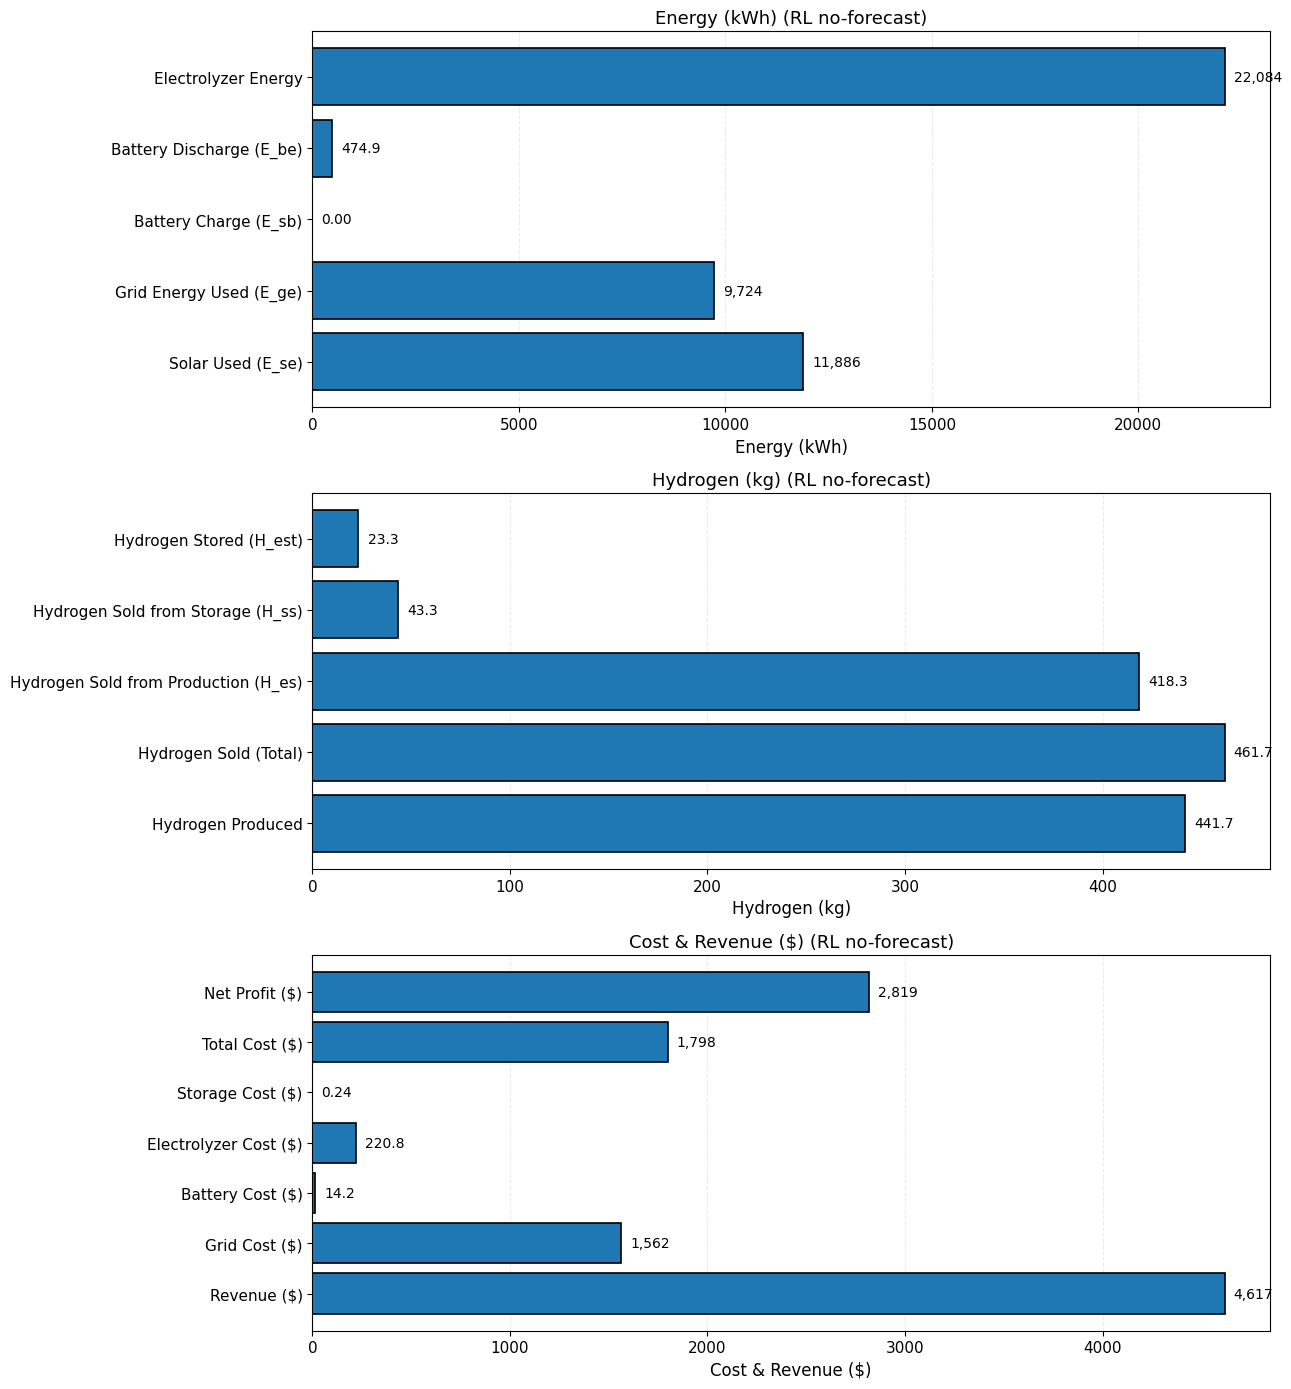

In [9]:
# --- report ---
kpis_rl_nf = report_rl_results(logs_rl_nf, title_suffix="(RL no-forecast)")

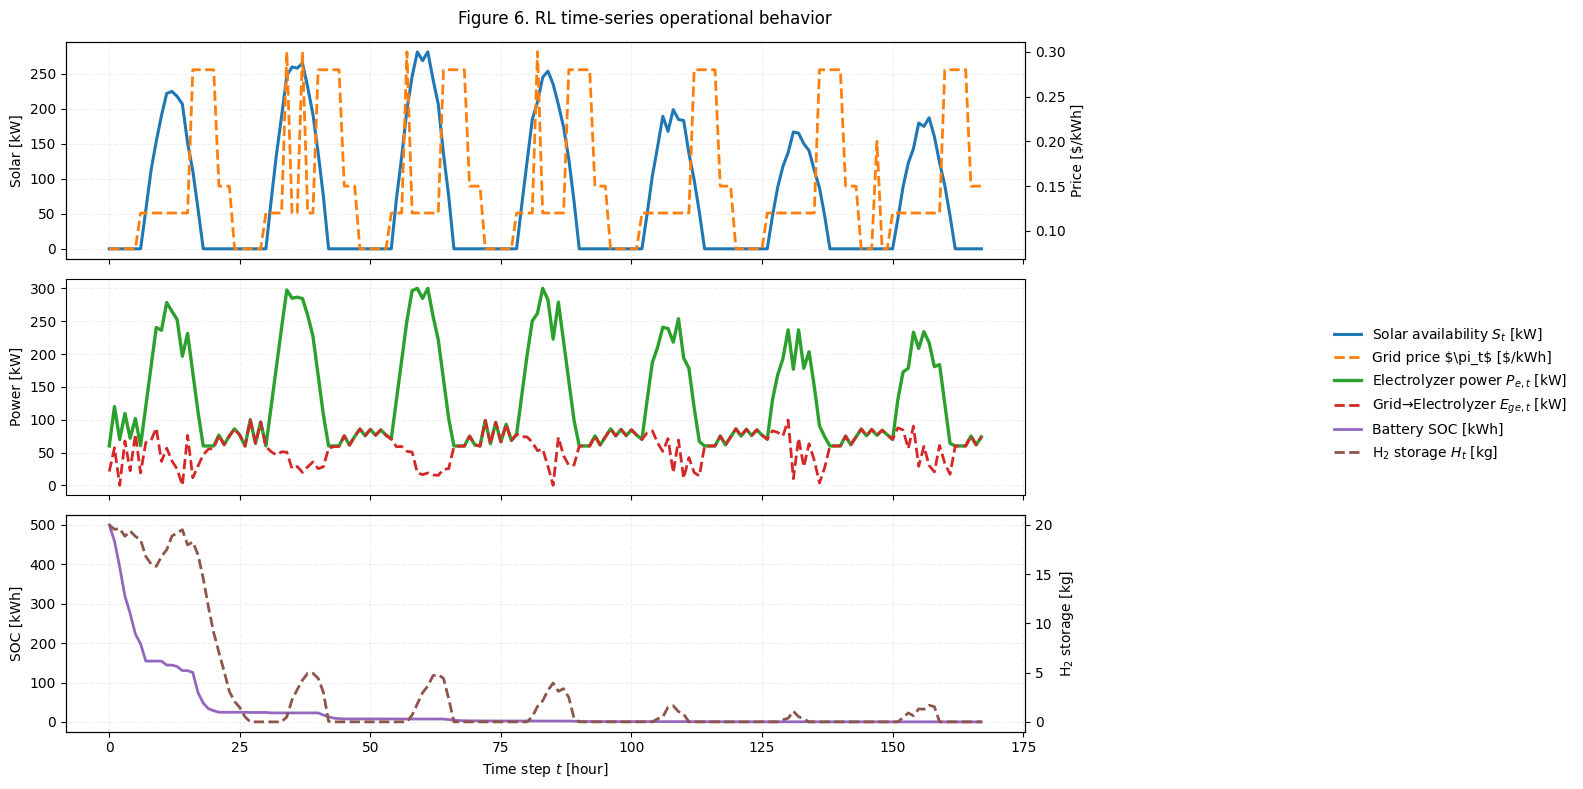

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fig6_rl_timeseries(logs_rl, savepath=None, show=True,
                            title="Figure 6. RL time-series operational behavior"):
    """
    Same Figure-6 plotting style as MPC, but for RL logs.
    Expects logs_rl keys: "solar", "P_elec", "E_ge", "SOC", "H_store"
    Requires: real_grid_price(t) available in scope.
    """

    t = np.arange(len(logs_rl["P_elec"]))

    solar  = np.asarray(logs_rl["solar"], dtype=float)
    P_elec = np.asarray(logs_rl["P_elec"], dtype=float)
    E_ge   = np.asarray(logs_rl["E_ge"], dtype=float)
    SOC    = np.asarray(logs_rl["SOC"], dtype=float)
    H_store= np.asarray(logs_rl["H_store"], dtype=float)

    price = np.array([real_grid_price(int(k)) for k in t], dtype=float)

    # Color palette (identical to MPC/RBC for consistency)
    COL_SOLAR = "#1f77b4"
    COL_PRICE = "#ff7f0e"
    COL_ELEC  = "#2ca02c"
    COL_GRID  = "#d62728"
    COL_SOC   = "#9467bd"
    COL_H2    = "#8c564b"

    fig, axs = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
    fig.suptitle(title, y=0.98)

    # -------------------------
    # (a) Solar + Price
    # -------------------------
    ax = axs[0]
    l1 = ax.plot(t, solar, color=COL_SOLAR, linewidth=2.2,
                 label="Solar availability $S_t$ [kW]")
    ax.set_ylabel("Solar [kW]")
    ax.grid(True, alpha=0.2, linestyle="--")

    ax_r = ax.twinx()
    l2 = ax_r.plot(t, price, color=COL_PRICE, linestyle="--", linewidth=2.0,
                   label="Grid price $\\pi_t$ [$/kWh]")
    ax_r.set_ylabel("Price [$/kWh]")

    # -------------------------
    # (b) Electrolyzer + Grid
    # -------------------------
    ax = axs[1]
    l3 = ax.plot(t, P_elec, color=COL_ELEC, linewidth=2.4,
                 label="Electrolyzer power $P_{e,t}$ [kW]")
    l4 = ax.plot(t, E_ge, color=COL_GRID, linestyle="--", linewidth=2.0,
                 label="Grid→Electrolyzer $E_{ge,t}$ [kW]")
    ax.set_ylabel("Power [kW]")
    ax.grid(True, alpha=0.2, linestyle="--")

    # -------------------------
    # (c) SOC + H2 storage
    # -------------------------
    ax = axs[2]
    l5 = ax.plot(t, SOC, color=COL_SOC, linewidth=2.0,
                 label="Battery SOC [kWh]")
    ax.set_ylabel("SOC [kWh]")
    ax.grid(True, alpha=0.2, linestyle="--")

    ax_r = ax.twinx()
    l6 = ax_r.plot(t, H_store, color=COL_H2, linestyle="--", linewidth=2.0,
                   label="H$_2$ storage $H_t$ [kg]")
    ax_r.set_ylabel("H$_2$ storage [kg]")

    axs[2].set_xlabel("Time step $t$ [hour]")

    # -------------------------
    # Global legend outside
    # -------------------------
    lines = l1 + l2 + l3 + l4 + l5 + l6
    labels = [line.get_label() for line in lines]

    fig.legend(lines, labels,
               loc="center left",
               bbox_to_anchor=(1.02, 0.5),
               frameon=False)

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    plt.close(fig)



plot_fig6_rl_timeseries(logs_rl_nf)